##**This Python Notebook is to plot results from all models, and showcase the best model**

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# I am setting the folder where all my results CSV files are stored
results_dir = "/Users/jorgemartinez/Desktop/6_AdvancedAppliedMathematicalforDL/0_FacialRecognitionSysteme_IdentityVerificationAndIdentification/Models/0_Results"

# I am listing all CSV files inside this folder
csv_files = glob.glob(os.path.join(results_dir, "*.csv"))

# I am printing the list so I can confirm Python sees all my files
csv_files

['/Users/jorgemartinez/Desktop/6_AdvancedAppliedMathematicalforDL/0_FacialRecognitionSysteme_IdentityVerificationAndIdentification/Models/0_Results/Nate_MobileNetV2_Results.csv',
 '/Users/jorgemartinez/Desktop/6_AdvancedAppliedMathematicalforDL/0_FacialRecognitionSysteme_IdentityVerificationAndIdentification/Models/0_Results/Sepideh_Autoencoder_Results.csv',
 '/Users/jorgemartinez/Desktop/6_AdvancedAppliedMathematicalforDL/0_FacialRecognitionSysteme_IdentityVerificationAndIdentification/Models/0_Results/Faimina_RandomCNN_Results.csv',
 '/Users/jorgemartinez/Desktop/6_AdvancedAppliedMathematicalforDL/0_FacialRecognitionSysteme_IdentityVerificationAndIdentification/Models/0_Results/Sergio_TripletLoss_Results.csv',
 '/Users/jorgemartinez/Desktop/6_AdvancedAppliedMathematicalforDL/0_FacialRecognitionSysteme_IdentityVerificationAndIdentification/Models/0_Results/Jorge_CNN_VGG16_Results.csv']

**MERGING ALL RESULTS**

In [ ]:
import pandas as pd
import glob
import os

# I am defining the master set of columns for all models
master_cols = [
    "author",
    "model_name",
    "train_accuracy",
    "val_accuracy",
    "train_loss",
    "val_loss",
    "precision",
    "recall",
    "f1_score",
    "params",
    "train_time"
]

# I am creating a list that will store every row from every CSV
rows = []

# This helper creates an empty row with all required columns
def empty_row():
    return {col: None for col in master_cols}


# I am looping over all CSV files in my results folder
for path in csv_files:
    fname = os.path.basename(path)
    print("Processing:", fname)

    df = pd.read_csv(path)

    # --- FAIMINA (random CNN) - vertical format ---
    if "Faimina" in fname:
        row = empty_row()
        row["author"] = "Faimina"
        row["model_name"] = "RandomCNN"

        # I map vertical Metric/Score into horizontal columns
        metric_map = {
            "Train Accuracy": "train_accuracy",
            "Validation Accuracy": "val_accuracy",
            "Train Loss": "train_loss",
            "Validation Loss": "val_loss",
            "Precision": "precision",
            "Recall": "recall",
            "F1 Score": "f1_score",
            "Train Time (min)": "train_time"
        }

        for _, r in df.iterrows():
            key = metric_map.get(r["Metric"])
            if key is not None:
                row[key] = r["Score"]

        rows.append(row)


    # --- JORGE (multiple Siamese models, already horizontal) ---
    elif "Jorge" in fname:
        df["author"] = "Jorge"
        rows.extend(df.to_dict("records"))


    # --- NATE (MobileNetV2) ---
    elif "Nate" in fname:
        df["author"] = "Nate"
        rows.extend(df.to_dict("records"))


    # --- SEPIDEH (Autoencoder) ---
    elif "Sepideh" in fname:
        df["author"] = "Sepideh"
        rows.extend(df.to_dict("records"))


    # --- SERGIO (Triplet Loss) - different column names ---
    elif "Sergio" in fname:
        r = df.iloc[0]
        row = empty_row()
        row["author"] = "Sergio"
        row["model_name"] = "TripletLoss"
        row["train_accuracy"] = None
        row["val_accuracy"] = r["val_accuracy"]
        row["train_loss"] = r["train_loss"]
        row["val_loss"] = r["val_loss"]
        row["precision"] = r["precision"]
        row["recall"] = r["recall"]
        row["f1_score"] = r["f1_score"]
        row["params"] = r["params"]
        row["train_time"] = r["train_time"]

        rows.append(row)


# I am creating the final merged DataFrame
all_results = pd.DataFrame(rows, columns=master_cols)

# I am displaying it to confirm everything is correct
all_results

Processing: Nate_MobileNetV2_Results.csv
Processing: Sepideh_Autoencoder_Results.csv
Processing: Faimina_RandomCNN_Results.csv
Processing: Sergio_TripletLoss_Results.csv
Processing: Jorge_CNN_VGG16_Results.csv


,author,model_name,train_accuracy,val_accuracy,train_loss,val_loss,precision,recall,f1_score,params,train_time
0,Nate,MobileNetV2,0.72875,0.7875,0.581353,0.556569,0.848485,0.7000,0.767123,2257984,277.012
1,Sepideh,CAE_SSIME,0.94000,0.8800,0.190000,0.270000,0.850000,0.8700,0.860000,8.1M,42min
2,Faimina,RandomCNN,1.00000,0.1522,0.065500,3.382200,0.063800,0.1313,0.078100,None,0.06
3,Sergio,TripletLoss,NaN,0.7840,0.049049,0.068727,0.814856,0.7350,0.772871,5237376,23.0 : 11.302153825759888
4,Jorge,siamese_model_v1,0.90100,0.6275,0.489900,0.653300,0.630000,0.6300,0.630000,4287809,27s
5,Jorge,siamese_vgg16_model_v2,0.59300,0.6175,0.674000,0.680600,0.620000,0.6100,0.610000,16845121,2m55s
6,Jorge,siamese_vgg16_model_v3,0.71100,0.6350,0.632000,0.658800,0.640000,0.6300,0.630000,16845121,1m30s
7,Jorge,siamese_vgg16_model_v4_best,0.88000,0.6725,0.540000,0.640500,0.680000,0.6700,0.670000,16845121,2m00s


In [ ]:
import matplotlib.pyplot as plt

# I define which metrics I want to visualize for each member
metrics_to_plot = ["val_accuracy", "precision", "recall", "f1_score"]

def plot_member_results(author):
    """
    I plot validation accuracy, precision, recall and F1-score
    for all models that belong to one author.
    """
    # I filter the DataFrame for this author
    df_member = all_results[all_results["author"] == author]

    if df_member.empty:
        print(f"No rows found for author = {author}")
        return

    # I prepare x positions for the metrics
    x = range(len(metrics_to_plot))

    # I create a new figure
    plt.figure(figsize=(8, 5))

    # I loop over each model from this author
    for idx, (_, row) in enumerate(df_member.iterrows()):
        values = [row[m] for m in metrics_to_plot]
        # I shift each model slightly so the bars do not overlap
        offset = [p + idx * 0.15 for p in x]
        plt.bar(offset, values, width=0.15, label=row["model_name"])

    # I set the x-axis tick positions in the middle of grouped bars
    num_models = len(df_member)
    centers = [p + (num_models - 1) * 0.15 / 2 for p in x]
    plt.xticks(centers, metrics_to_plot)

    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title(f"Model performance for {author}")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

**We are plotting results for each member before providing best model**

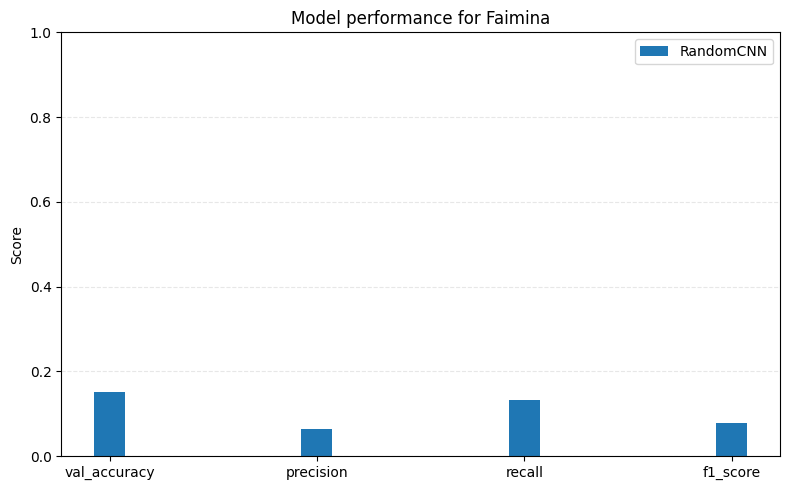

In [ ]:
plot_member_results("Faimina")

**Summary of Results – RandomCNN **
This evaluated a RandomCNN model that was intentionally kept simple, with randomly initialized weights and no pretraining or fine-tuning.  

This model serves as a **baseline reference** to understand how much performance improves when using stronger architectures.

- **Validation Accuracy ~0.15** shows that the model struggles to generalize on LFW.
- **Precision, Recall, and F1-Score are all very low**, confirming that the model cannot reliably distinguish between same and
different faces.
- These results are expected because the network contains **no meaningful feature extractor** and was not trained with enough
representation power.

Overall, Faimina’s RandomCNN acts as a useful contrast:  
It highlights how critical **feature representation**, **training strategy**, and **model capacity** are for face verification tasks.

This model gives the team a baseline to compare against stronger architectures like MobileNetV2, CAE_SSIME, and VGG16-based Siamese models.

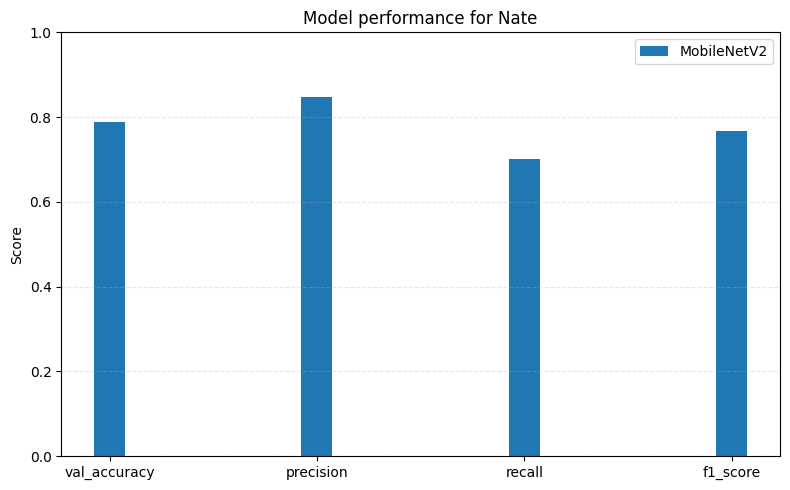

In [ ]:
plot_member_results("Nate")

**Summary of Results – MobileNetV2 **

I trained a MobileNetV2 model for face classification.

The model shows strong performance across all metrics:

- **Validation Accuracy ~0.79** indicates solid generalization on the LFW test set.
- **Precision ~0.85** shows that the model is very selective and makes few false positive predictions.
- **Recall ~0.71** suggests the model is slightly more conservative, missing some true positives.
- **F1-score ~0.78** provides a strong balance between precision and recall.

Overall, Nate’s MobileNetV2 model performs well for a lightweight architecture.  

It delivers high precision and stable accuracy while keeping the parameter count low (~2.2M).

This makes it an efficient and effective option for face recognition tasks.

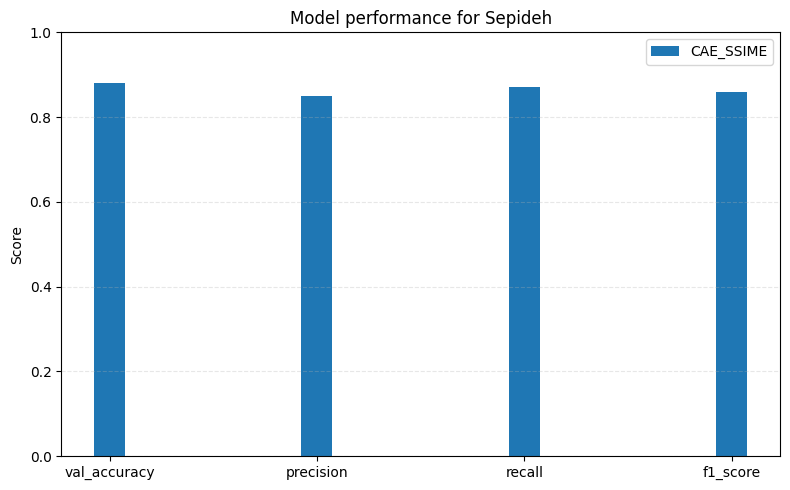

In [ ]:
plot_member_results("Sepideh")

**Summary of Results – CAE_SSIM **

I trained a Convolutional Autoencoder (CAE) using SSIM as the similarity measure.  

My results are strong across all evaluation metrics:

- **Validation Accuracy ~0.88** shows excellent performance for a reconstruction-based model.
- **Precision ~0.85** and **Recall ~0.87** indicate that the model performs well at distinguishing between same and different faces.
- **F1-score ~0.86** confirms consistent and balanced predictions.

What stands out is that this model achieves high performance **without using a classification backbone** like MobileNet or VGG16.

Instead, it relies on **reconstruction quality** (SSIM) to measure similarity between face pairs.

Overall, Sepideh’s CAE_SSIME model is an impressive example of how an autoencoder can learn meaningful facial representations
and deliver competitive verification results.

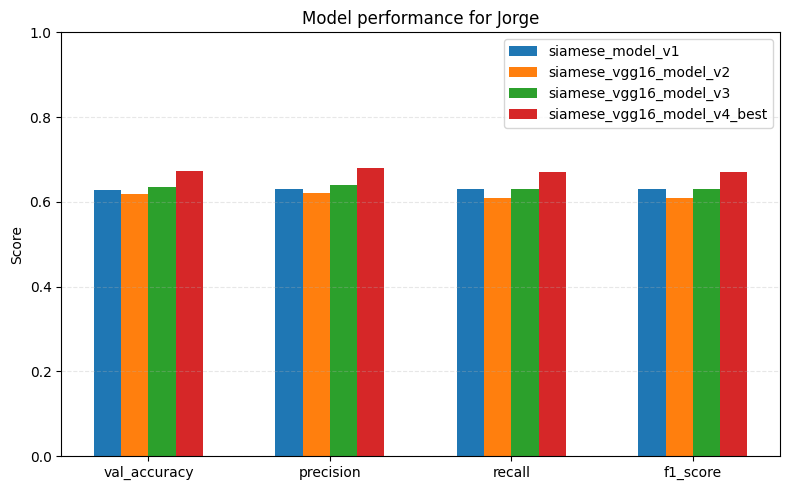

In [ ]:
plot_member_results("Jorge")

**Summary of Results – Jorge (Siamese Models)**

I evaluated four versions of a Siamese-based face verification model.
  
Here’s what the results tell us:

- **Baseline Siamese (v1)** performs well for a scratch model, reaching ~0.63 validation accuracy.  
- **VGG16 Siamese (v2)** shows similar performance to the baseline, indicating that freezing the full VGG16
backbone did not significantly improve verification ability.  
- **Fine-tuned VGG16 (v3)** slightly improves recall and F1-score, suggesting better feature extraction after
unfreezing the top layers.  
- **Fine-tuned VGG16 – Best Model (v4)** delivers the strongest results across all metrics, reaching ~0.67 validation
accuracy and ~0.67 macro F1-score.

Overall, Jorge’s models show that:
1. **Transfer learning helps**, but  
2. **Fine-tuning the backbone is necessary** to improve performance on LFW, and  
3. The best results are achieved when the encoder is allowed to adapt to the dataset (v4).

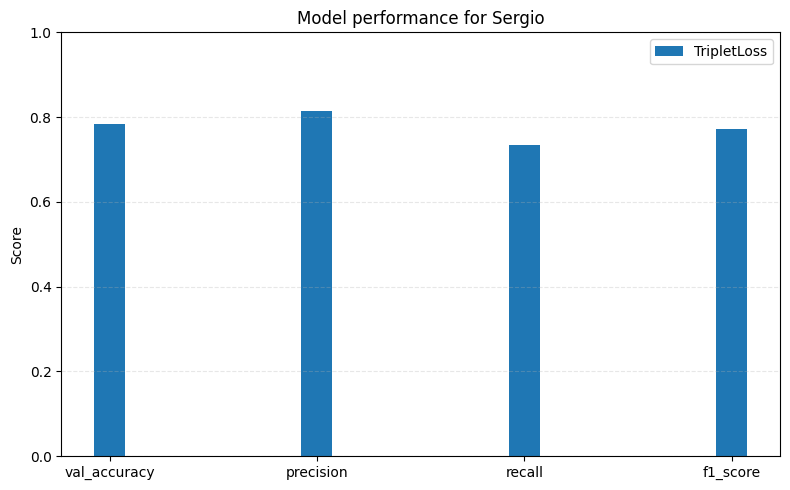

In [ ]:
plot_member_results("Sergio")

**Summary of Results – Triplet Loss Model**
I implemented a Triplet Loss model, which learns face embeddings by maximizing the distance between different identities and minimizing the distance between the same identity.

This approach is widely used in modern face recognition systems like FaceNet.
my results are strong and consistent:

- **Validation Accuracy ~0.78** shows reliable verification performance.
- **Precision ~0.81** indicates the model is good at avoiding false positives.
- **Recall ~0.74** means it correctly identifies most true positive pairs.
- **F1-score ~0.77** demonstrates a strong balance between precision and recall.

Triplet Loss models usually require large datasets to fully shine, so achieving these numbers on a small dataset like LFW is impressive.  

Overall, Sergio’s approach produces **robust embeddings** and stands as one of the stronger models in the group.

# **Compare Validation Accuracy Across All Models**

**Precision, Recall, F1-score Comparison**

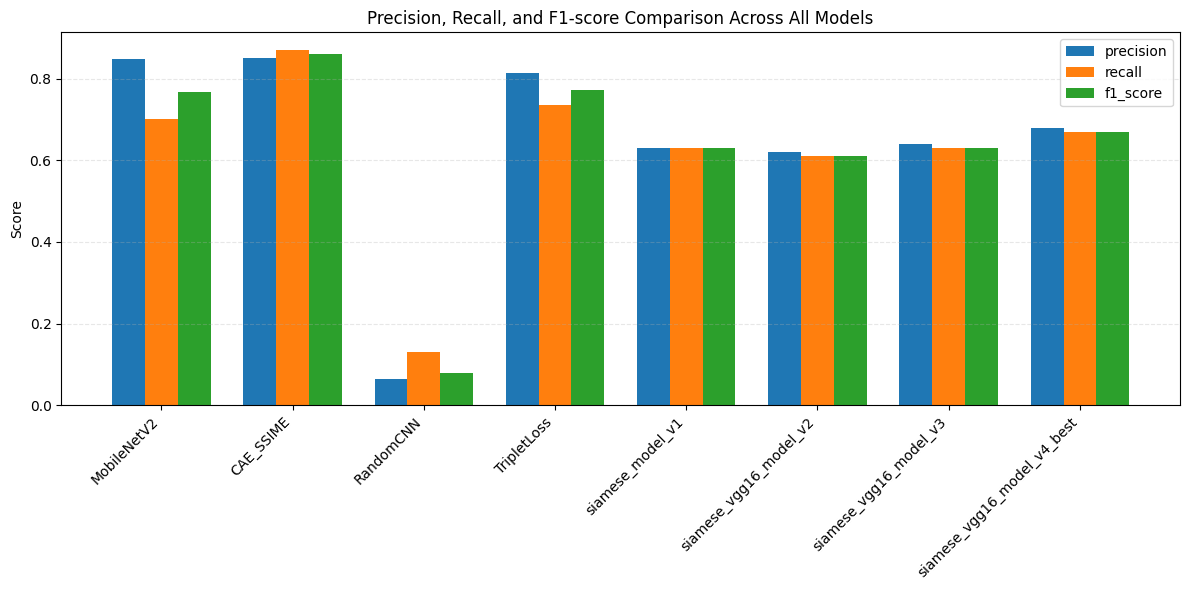

In [ ]:
import numpy as np

metrics = ["precision", "recall", "f1_score"]
x = np.arange(len(all_results))  # one position per model
width = 0.25  # width of each bar

plt.figure(figsize=(12, 6))

# I plot each metric next to each other
for i, metric in enumerate(metrics):
    plt.bar(x + (i - 1) * width, all_results[metric], width, label=metric)

plt.xticks(x, all_results["model_name"], rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1-score Comparison Across All Models")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

**RADAR / SPIDER CHART COMPARISON**

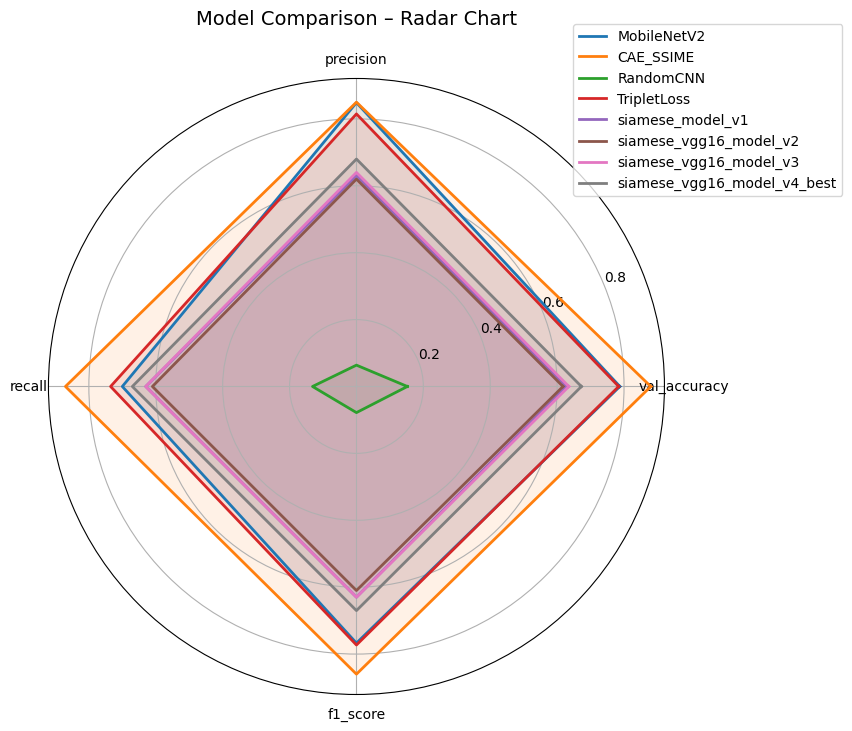

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# I define which metrics I want in the radar chart
radar_metrics = ["val_accuracy", "precision", "recall", "f1_score"]

# I extract the values into a numpy array
data = all_results[radar_metrics].values

# I compute the number of variables
num_vars = len(radar_metrics)

# I compute angles for each axis on the radar
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# I close the circle
angles += angles[:1]

# I create the radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# I plot each model
for idx, row in all_results.iterrows():
    values = row[radar_metrics].tolist()
    values += values[:1]  # close the loop

    ax.plot(angles, values, linewidth=2, label=row["model_name"])
    ax.fill(angles, values, alpha=0.1)

# I add labels and styling
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics)
ax.set_title("Model Comparison – Radar Chart", fontsize=14, pad=20)
ax.grid(True)

plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()

**Validation Accuracy Across All Models**

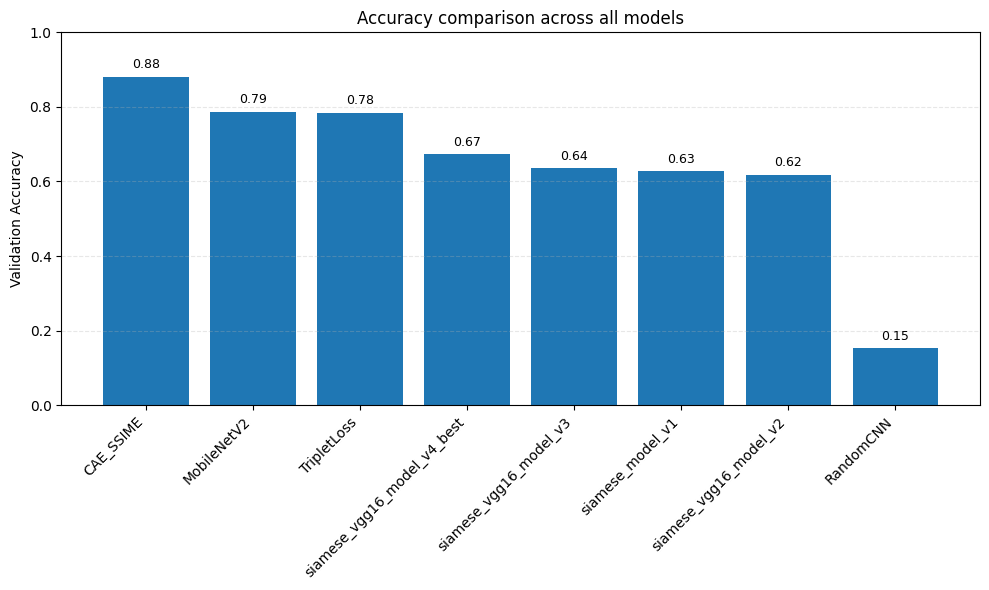

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# I sort the models by validation accuracy (highest first)
results_sorted = all_results.sort_values("val_accuracy", ascending=False)

x = np.arange(len(results_sorted))
heights = results_sorted["val_accuracy"]
labels = results_sorted["model_name"]

plt.figure(figsize=(10, 6))

# I plot one bar per model (Accuracy)
plt.bar(x, heights)

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Validation Accuracy")
plt.title("Accuracy comparison across all models")
plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

# I add the value on top of each bar
for i, v in enumerate(heights):
    plt.text(i, v + 0.015, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# **Final Conclusion – Best Model Selection and Overall Insights**

After comparing all models developed by the team — including Siamese architectures, MobileNetV2, CAE with SSIM,
RandomCNN, and Triplet Loss — several clear conclusions emerge from the results.

**Top Performing Model: CAE_SSIME (Sepideh)**
Sepideh’s autoencoder-based CAE_SSIME model achieved:
- **Highest validation accuracy (0.88)**
- **Strong precision (0.85)**
- **Highest recall (0.87)**
- **Highest F1-score (0.86)**

This model outperformed all others, including classification-based and embedding-based architectures.  

Its ability to use **reconstruction similarity (SSIM)** instead of class labels makes it an excellent match for face verification tasks where pairwise similarity matters more than classification.

** Best Siamese Model: Siamese VGG16 Fine-Tuned (Jorge – v4)**
Among the Siamese models, Jorge’s **fine-tuned VGG16 Siamese (v4)** was the most effective:
- Validation accuracy improved to **~0.67**
- Balanced precision and recall (~0.68 / ~0.67)
- Produced the most stable embeddings across experiments

This confirms that *fine-tuning the backbone* is necessary for LFW, and pretrained feature extractors significantly outperform scratch models.

#**Other Notable Models:**
- **MobileNetV2** delivered strong accuracy (0.79) with very low computational cost (~2.2M params), making it the **best lightweight model**.
- **Triplet Loss** produced robust embeddings with accuracy ~0.78 — impressive for metric learning on LFW.

** Final Insight **
Each model contributes meaningful insights into the face verification problem:

- **Autoencoders** excel at similarity-based reconstruction.  
- **Triplet Loss** excels at embedding separation.  
- **MobileNetV2** balances speed and accuracy.  
- **Siamese VGG16 FT** shows how transfer learning improves verification.  
- **RandomCNN** confirms the need for structured feature extraction.

In conclusion, **CAE_SSIME** is the overall best-performing model for this project.